## Fase 3 — Camada Gold: Análise e Visualização

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

import banco

pd.options.display.float_format = 'R$ {:,.2f}'.format

conexao = banco.conectar()
print("Conectado ao banco com sucesso.")


Conectado ao banco com sucesso.


### Pergunta 1:


In [ ]:
sql_q1 = '''
    SELECT nome_orgao_superior,
           SUM(valor_total) AS custo_total
    FROM silver_viagem
    GROUP BY nome_orgao_superior
    ORDER BY custo_total DESC
    LIMIT 5
'''
df_q1 = pd.read_sql(sql_q1, conexao)
df_q1


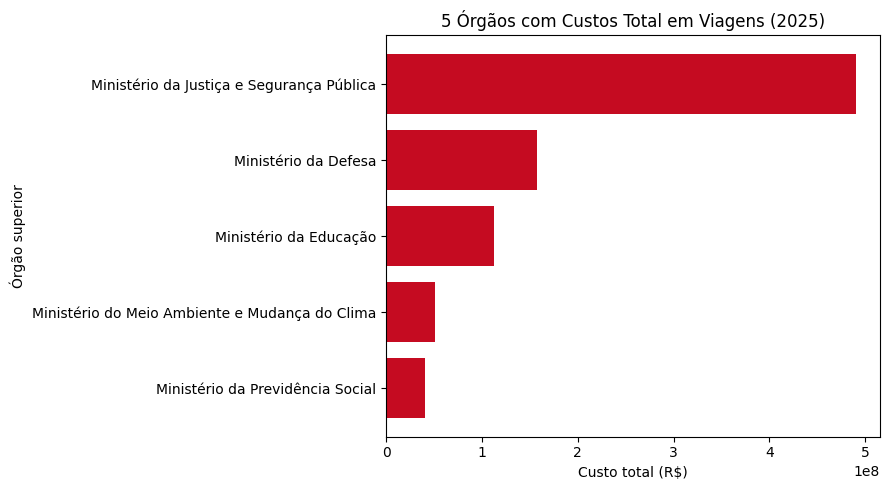

In [18]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(df_q1['nome_orgao_superior'], df_q1['custo_total'], color="#c50b21")
ax.set_xlabel('Custo total (R$)')
ax.set_ylabel('Órgão superior')
ax.set_title('5 Órgãos com Custos Total em Viagens (2025)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()


Após as análises é possível observar que a maior parte dos gastos com viagens está em apenas dois ministérios: Justiça e Segurança Pública (R$ 490,8 milhões) e Defesa (R$ 157,1 milhões). Juntos, eles lideram as despesas por causa do trabalho de campo contínuo de órgãos como Polícia Federal, Polícia Rodoviária Federal e Forças Armadas. Outros ministérios, como Educação, Meio Ambiente e Previdência Social, têm custos bem menores (entre R$ 41 e R$ 112 milhões), o que mostra que esse gasto depende do tipo de operação de cada área.

---
### Pergunta 2: Quais os 3 destinos com maior custo médio por viagem?


In [ ]:
sql_q2_bruto = '''
    SELECT id_viagem, destinos, valor_total
    FROM silver_viagem
    WHERE destinos IS NOT NULL
'''
df_bruto = pd.read_sql(sql_q2_bruto, conexao)

linhas = []
for _, linha in df_bruto.iterrows():
    destinos_unicos = {d.strip() for d in linha['destinos'].split(',') if d.strip()}
    for destino in destinos_unicos:
        linhas.append({'id_viagem': linha['id_viagem'], 'destino': destino, 'valor_total': linha['valor_total']})

df_destinos = pd.DataFrame(linhas)


resumo_destinos = (
    df_destinos.groupby('destino')
    .agg(custo_medio=('valor_total', 'mean'), qtd_viagens=('id_viagem', 'nunique'))
    .reset_index()
)

resumo_destinos = resumo_destinos[resumo_destinos['qtd_viagens'] >= 5]
df_q2 = resumo_destinos.sort_values('custo_medio', ascending=False).head(3).reset_index(drop=True)
df_q2

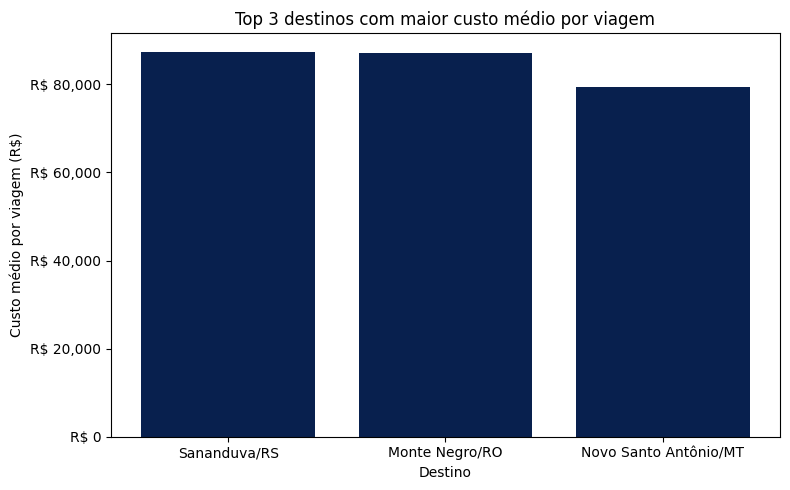

In [20]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(df_q2['destino'].astype(str), df_q2['custo_medio'], color="#08204e")
ax.set_xlabel('Destino')
ax.set_ylabel('Custo médio por viagem (R$)')
ax.set_title('Top 3 destinos com maior custo médio por viagem')
ax.yaxis.set_major_formatter(lambda x, pos: f'R$ {x:,.0f}')
plt.xticks(rotation=0, ha='center')
plt.tight_layout()
plt.show()

Observa-se que as viagens mais caras, são para cidades pequenas, como Sananduva (RS), Monte Negro (RO) e Novo Santo Antônio (MT). Por serem locais de difícil acesso, o custo aumenta por causa dos trajetos mais longos, onde não se encontram transportes diretos e com isso geram maior tempo de viagem, o que gera mais diárias. 

### Pergunta 3: Qual a viagem de maior duração e seu custo total?

In [ ]:
sql_q3 = '''
    SELECT id_viagem, nome_orgao_superior, nome_viajante,
           data_inicio, data_fim, duracao_dias, valor_total
    FROM silver_viagem
    WHERE duracao_dias IS NOT NULL
    ORDER BY duracao_dias DESC
    LIMIT 1
'''
df_q3 = pd.read_sql(sql_q3, conexao)
df_q3

In [ ]:
sql_check = """
    SELECT *
    FROM raw_viagem
    WHERE id_viagem = '0000000000020699856'
"""
pd.read_sql(sql_check, conexao)

Foi verificado diretamente no raw se havia algum erro por o valor estar zerado, e observou-se que estava correto fazendo a busca diretamente pelo id da viagem.

C:\Users\Larissa\AppData\Local\Temp\ipykernel_11452\540305166.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  media_duracao = pd.read_sql(sql_media_duracao, conexao)['media'][0]


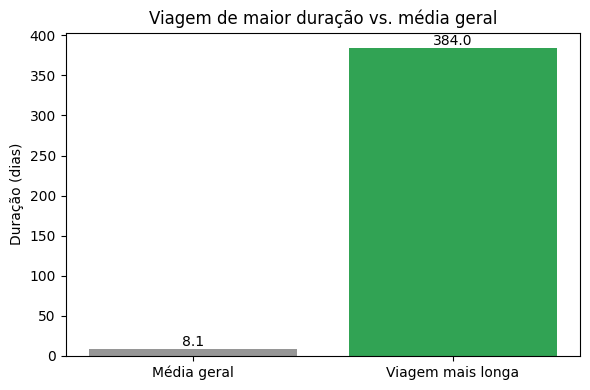

In [26]:
sql_media_duracao = "SELECT AVG(duracao_dias) AS media FROM silver_viagem WHERE duracao_dias IS NOT NULL"
media_duracao = pd.read_sql(sql_media_duracao, conexao)['media'][0]

fig, ax = plt.subplots(figsize=(6, 4))
categorias = ['Média geral', 'Viagem mais longa']
valores = [media_duracao, df_q3['duracao_dias'][0]]
ax.bar(categorias, valores, color=['#969696', '#31a354'])
ax.set_ylabel('Duração (dias)')
ax.set_title('Viagem de maior duração vs. média geral')
for i, v in enumerate(valores):
    ax.text(i, v, f'{v:.1f}', ha='center', va='bottom')
plt.tight_layout()
plt.show()


A viagem mais longa registrada durou 384 dias (no Ministério da Previdência Social), mas não se trata de um deslocamento comum. É o caso de um servidor convocado para trabalhar presencialmente em outro local por um longo período. Por isso, o custo total foi R$ 0,00 na base de dados — sem gastos com diárias ou passagens. 

In [ ]:
banco.executar(conexao, "DROP TABLE IF EXISTS gold_resumo_orgao;")

sql_gold_tabela = '''
    CREATE TABLE gold_resumo_orgao AS
    SELECT
        v.cod_orgao_superior,
        v.nome_orgao_superior,
        COUNT(DISTINCT v.id_viagem)      AS qtd_viagens,
        SUM(v.valor_total)               AS custo_total_viagens,
        AVG(v.duracao_dias)              AS duracao_media_dias,
        COALESCE(SUM(p.valor), 0)        AS total_pago
    FROM silver_viagem v
    LEFT JOIN silver_pagamento p ON v.id_viagem = p.id_viagem
    GROUP BY v.cod_orgao_superior, v.nome_orgao_superior
'''
banco.executar(conexao, sql_gold_tabela)

banco.executar(conexao, "DROP VIEW IF EXISTS vw_gold_resumo_orgao;")
sql_gold_view = '''
    CREATE VIEW vw_gold_resumo_orgao AS
    SELECT
        v.cod_orgao_superior,
        v.nome_orgao_superior,
        COUNT(DISTINCT v.id_viagem)      AS qtd_viagens,
        SUM(v.valor_total)               AS custo_total_viagens,
        AVG(v.duracao_dias)              AS duracao_media_dias,
        COALESCE(SUM(p.valor), 0)        AS total_pago
    FROM silver_viagem v
    LEFT JOIN silver_pagamento p ON v.id_viagem = p.id_viagem
    GROUP BY v.cod_orgao_superior, v.nome_orgao_superior
'''
banco.executar(conexao, sql_gold_view)

print("Tabela gold_resumo_orgao e view vw_gold_resumo_orgao criadas com sucesso.")
pd.read_sql("SELECT * FROM gold_resumo_orgao LIMIT 5", conexao)


Camada Gold

In [ ]:
sql_q4 = '''
    SELECT nome_orgao_superior, total_pago
    FROM vw_gold_resumo_orgao
    ORDER BY total_pago DESC
    LIMIT 5
'''
df_q4 = pd.read_sql(sql_q4, conexao)
df_q4


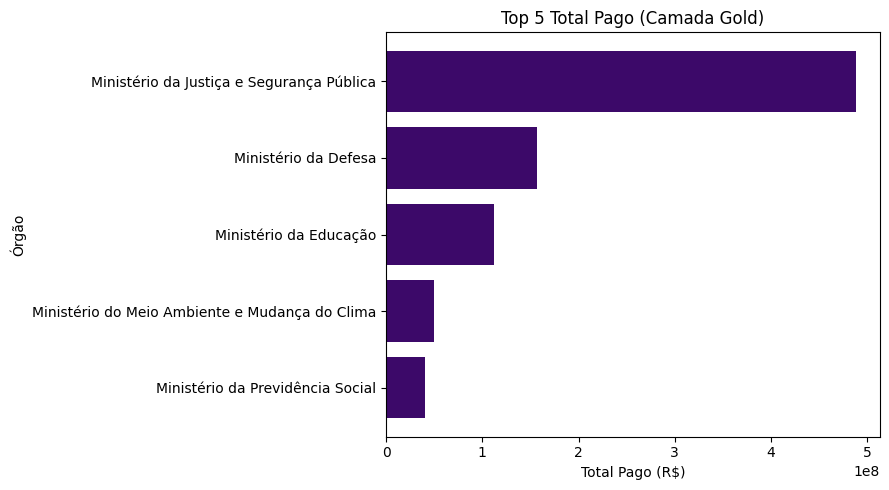

In [30]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(df_q4['nome_orgao_superior'], df_q4['total_pago'], color="#3c0969")
ax.set_xlabel('Total Pago (R$)')
ax.set_ylabel('Órgão')
ax.set_title('Top 5 Total Pago (Camada Gold)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()


Por comparação é possível observar que ao mesmo tempo que o Ministério da Justiça e Segurança Pública tem os maiores custos, é o mesmo que acaba por ter os maiores valores pagos.

In [31]:
sql_q5 = '''
    SELECT tipo_pagamento, AVG(valor) AS valor_medio, COUNT(*) AS qtd
    FROM silver_pagamento
    GROUP BY tipo_pagamento
    ORDER BY valor_medio DESC
'''
df_q5 = pd.read_sql(sql_q5, conexao)
df_q5


C:\Users\Larissa\AppData\Local\Temp\ipykernel_11452\18967250.py:7: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_q5 = pd.read_sql(sql_q5, conexao)


,tipo_pagamento,valor_medio,qtd
0,DIÁRIAS,"R$ 2,078.28",401463
1,PASSAGEM,"R$ 1,878.34",188985
2,Serviço correlato: seguro,R$ 447.51,4894
3,RESTITUIÇÃO,R$ 245.70,11574


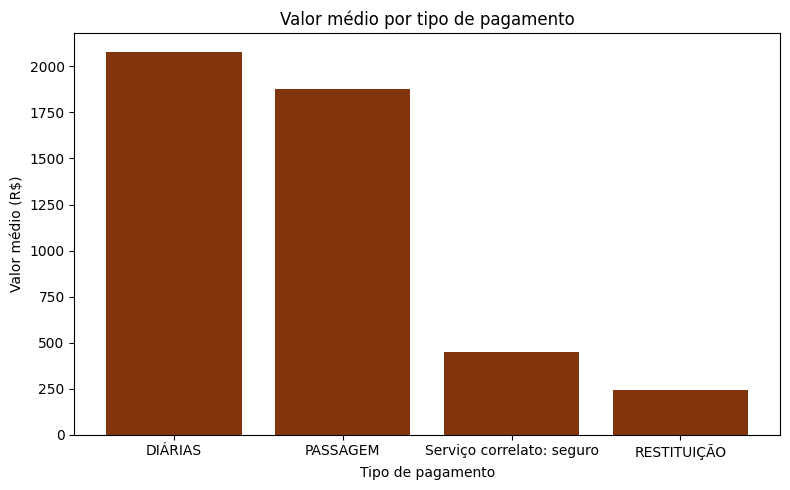

In [35]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(df_q5['tipo_pagamento'].astype(str), df_q5['valor_medio'], color="#82340d")
ax.set_xlabel('Tipo de pagamento')
ax.set_ylabel('Valor médio (R$)')
ax.set_title('Valor médio por tipo de pagamento')
plt.xticks(rotation=00, ha='center')
plt.tight_layout()
plt.show()



---
### Pergunta 6: Qual o meio de transporte mais usado nos trechos e qual UF
de destino aparece em mais trechos?


In [36]:
sql_q6a = '''
    SELECT meio_transporte, COUNT(*) AS qtd_trechos
    FROM silver_trecho
    WHERE meio_transporte IS NOT NULL
    GROUP BY meio_transporte
    ORDER BY qtd_trechos DESC
'''
df_q6a = pd.read_sql(sql_q6a, conexao)

sql_q6b = '''
    SELECT destino_uf, COUNT(*) AS qtd_trechos
    FROM silver_trecho
    WHERE destino_uf IS NOT NULL
    GROUP BY destino_uf
    ORDER BY qtd_trechos DESC
    LIMIT 10
'''
df_q6b = pd.read_sql(sql_q6b, conexao)

print("Meios de transporte:")
display(df_q6a)
print("Top 10 UFs de destino:")
display(df_q6b)


C:\Users\Larissa\AppData\Local\Temp\ipykernel_11452\2186557701.py:8: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_q6a = pd.read_sql(sql_q6a, conexao)
C:\Users\Larissa\AppData\Local\Temp\ipykernel_11452\2186557701.py:18: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_q6b = pd.read_sql(sql_q6b, conexao)


Meios de transporte:


,meio_transporte,qtd_trechos
0,Veículo Oficial,386424
1,Aéreo,232666
2,Rodoviário,64970
3,Veículo Próprio,42846
4,Inválido,26659
5,Fluvial,8429
6,Ferroviário,874
7,Marítimo,481


Top 10 UFs de destino:


,destino_uf,qtd_trechos
0,São Paulo,82722
1,Distrito Federal,79962
2,Minas Gerais,50965
3,Rio de Janeiro,44197
4,Paraná,42603
5,Pará,40044
6,Rio Grande do Sul,38684
7,Mato Grosso do Sul,30516
8,Bahia,28375
9,Pernambuco,28372


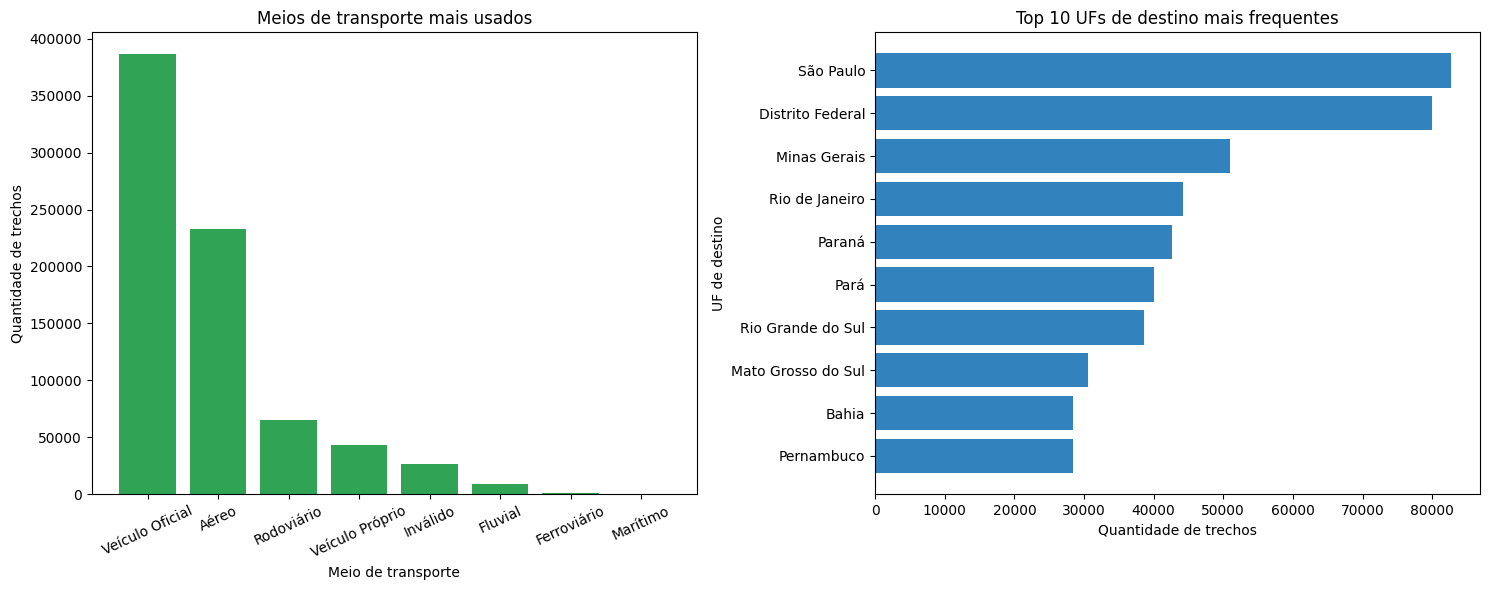

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

axes[0].bar(df_q6a['meio_transporte'].astype(str), df_q6a['qtd_trechos'], color='#31a354')
axes[0].set_xlabel('Meio de transporte')
axes[0].set_ylabel('Quantidade de trechos')
axes[0].set_title('Meios de transporte mais usados')
axes[0].tick_params(axis='x', rotation=25)

axes[1].barh(df_q6b['destino_uf'].astype(str), df_q6b['qtd_trechos'], color='#3182bd')
axes[1].set_xlabel('Quantidade de trechos')
axes[1].set_ylabel('UF de destino')
axes[1].set_title('Top 10 UFs de destino mais frequentes')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

São Paulo e Distrito Federal lideram  volume de viagens, com 82,7 mil e 80 mil trechos, e observa-se uma elevada diferença para o do terceiro colocado, Minas Gerais (51 mil).
Espera-se este resultado pois Brasília é o centro político do país e São Paulo é o principal polo econômico e de transportes. 
Os meios de transportes mais utilizados foram veículos oficiais e áereos decorrente de que muitas vezes as viagens necessitavam deslocamento ágil para conseguirem cumprir sas obrigações.

In [ ]:
conexao.close()
print("Conexão encerrada.")


 - - -

 ### Conclusão:


A análise dos dados de Viagens a Serviço mostra uma alta concentração de custos e volume em poucos órgãos e destinos específicos, como os gastos concentrados na Segurança e Defesa onde o Ministério da Justiça lidera os custos logo em seguida vem o Ministério da Defesa. Isso ocorre porque órgãos como Polícia Federal, PRF e Forças Armadas exigem presença física constante em todo o país.

São Paulo e Brasília concentram a maioria das viagens, mas têm custo médio menor devido à facilidade de transporte e oferta de voos.

Os meios mais utilizados foram veículos oficiais e áereos.
